### Import librairies

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, weights, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

from python_module.pricing_model import BSMModel
from python_module.strike_reduction import (
    constrained_lasso, omp, option_risk_table, quick_terminal_payoff_lasso, quick_terminal_payoff_omp,
    terminal_payoff_lasso,
)

### Custom functions

In [2]:
# Functions used across the notebook. They read notebook variables (portfolio, strikes, X, y, ...) defined in the
# sections below, so they can be defined here and called once those sections have run.

# --- Option portfolio ---
def log_contract(S):
    """Log contract 2/T * [(S - S_star) / S_star - ln(S / S_star)] replicated by the variance swap strip."""
    return 2 / T * ((S - S_star) / S_star - np.log(S / S_star))


def intrinsic_values(spots):
    """Unit payoff at expiry of each option for each spot: shape (n_spots, n_options)."""
    spots = np.asarray(spots)[:, None]
    return np.where(is_call, np.maximum(spots - strikes, 0.0), np.maximum(strikes - spots, 0.0))


# --- Reduced portfolios ---
def r2(target, fitted):
    """Coefficient of determination of fitted vs target."""
    return 1 - ((target - fitted) ** 2).sum() / ((target - target.mean()) ** 2).sum()


def reduced_positions(result):
    """Selected options with their multiplier of the original quantity and the resulting reduced quantity."""
    reduced = portfolio.set_index("name").loc[result.weights.index, ["strike", "option_type", "quantity"]]
    reduced["multiplier"] = result.weights
    reduced["reduced_quantity"] = reduced["quantity"] * reduced["multiplier"]
    return reduced


def reduced_pnl(reduced):
    """Hedged P&L of a reduced portfolio on every path."""
    return X[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy()


def pnl_r2(reduced):
    """R2 of a reduced portfolio on the delta hedged P&L across all paths (common yardstick across objectives)."""
    return r2(y, reduced_pnl(reduced))


def weights_by_name(result):
    """Re-index a strike-indexed result by option name, as used by the other sections of the notebook."""
    return result._replace(weights=result.weights.rename(index=portfolio.set_index("strike")["name"]))


# --- Plots ---
def grid_payoff(reduced):
    """Terminal payoff of a reduced portfolio on the Terminal Payoff spot grid."""
    return intrinsic_df[reduced.index].to_numpy() @ reduced["reduced_quantity"].to_numpy()


def grid_gamma_cash_mm(reduced):
    """Gamma cash (mm) of a reduced portfolio on the Gamma Grid (spot x time)."""
    gamma_cash = X_gamma[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy()
    return gamma_cash.reshape(spot_grid.size, time_grid.size) / 1e6


def plot_strike_map(method_quantities):
    """Strike map of each method: y = strike, x = method, colour = sign of the quantity, dot area proportional to
    |quantity| (same size scale across methods so positions are directly comparable)."""
    dots = pd.concat(
        [q[q != 0].rename("quantity").reset_index().assign(method=m) for m, q in method_quantities.items()],
        ignore_index=True,
    )
    max_area = 600
    area_scale = max_area / dots["quantity"].abs().max()
    sign_colors = {True: "tab:green", False: "tab:red"}
    x_pos = {m: i for i, m in enumerate(method_quantities)}

    fig, ax = plt.subplots(figsize=(3 + 2 * len(x_pos), 8))
    ax.scatter(
        dots["method"].map(x_pos), dots["strike"],
        s=dots["quantity"].abs() * area_scale,
        c=(dots["quantity"] > 0).map(sign_colors),
        alpha=0.7, edgecolors="white", linewidths=0.5,
    )
    ax.axhline(S0, color="gray", linestyle="--", linewidth=1)

    # Legend: sign colours and reference sizes
    ref_sizes = [float(f"{q:.2g}") for q in np.array([0.1, 0.5, 1.0]) * dots["quantity"].abs().max()]
    handles = [plt.scatter([], [], s=60, color=sign_colors[True], label="Long"),
               plt.scatter([], [], s=60, color=sign_colors[False], label="Short")]
    handles += [plt.scatter([], [], s=q * area_scale, color="gray", alpha=0.5, label=f"{q:_.0f}") for q in ref_sizes]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), labelspacing=1.5, frameon=False, title="Quantity")

    ax.set_xticks(list(x_pos.values()), list(x_pos.keys()))
    ax.set_xlim(-0.6, len(x_pos) - 0.4)
    ax.set_ylabel("Strike")
    ax.set_title("Option quantities by strike per method")
    plt.tight_layout()
    plt.show()

### Inputs

In [3]:
# Pricing parameters
S0 = 100.0                                  # spot
T = 60 / 252                                # maturity (years)
r = 0.00                                    # risk-free rate
sigma = 0.20                                # volatility

# Monte Carlo parameters
n_paths = 10_000                            # MC paths (~0.1 MB per path at 20 steps x 100 options)
n_steps = max(1, round(T * 252))            # MC steps
seed = 42                                   # random seed
simulation_sigma = 0.20                     # volatility used for simulation

# Portfolio parameters
n_options = 100                             # number of options in the portfolio    
lower_bound_delta = -0.01                   # lower delta strike to be included in the portfolio
upper_bound_delta = 0.01                    # upper delta strike to be included in the portfolio
t0_gamma_cash = 50_000_000

# Strike reduction parameters
n_selected_options = 10                     # number of options kept by the reduction

# Risk constraints on (reduced - full portfolio) at t0
slide_shocks = [-0.05, -0.10]               # spot shocks of the delta hedged slides, each slide difference must be >= 0
vega_tolerance = 0.05                       # max relative vega difference vs the full portfolio

### Option portfolio creation

In [4]:
# Forward and strike bounds: closed-form inversion of the Black-76 delta
# call delta = disc * N(d1), put delta = disc * (N(d1) - 1), K = F * exp(-d1 * sigma * sqrt(T) + sigma^2 * T / 2)
F0 = BSMModel.compute_forward(S0, T, r, 0.0, 0.0)
discount = np.exp(-r * T)
d1_lower = ndtri(1 + lower_bound_delta / discount)
d1_upper = ndtri(upper_bound_delta / discount)
K_lower = F0 * np.exp(-d1_lower * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)
K_upper = F0 * np.exp(-d1_upper * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)

# Equally spaced strike grid; S_star is the node closest to the forward (put / call boundary)
strikes = np.linspace(K_lower, K_upper, n_options)
dK = strikes[1] - strikes[0]
S_star = strikes[np.argmin(np.abs(strikes - F0))]

# Variance swap replication (Demeterfi-Derman-Kamal-Zou): replicate the log contract
# f(S) = 2/T * [(S - S_star) / S_star - ln(S / S_star)] by its piecewise-linear interpolant on the strike nodes.
# The weight of each option is the slope change (kink) of the interpolant at its strike.
# One ghost node on each side lets the boundary strikes carry weight instead of being wasted.

nodes = np.concatenate([[K_lower - dK], strikes, [K_upper + dK]])
slopes = np.diff(log_contract(nodes)) / np.diff(nodes)
weights = np.diff(slopes)                                   # ~ 2 * dK / (T * K^2)

portfolio = pd.DataFrame({
    "strike": strikes,
    "option_type": np.where(strikes < S_star, "put", "call"),
    "weight": weights,
})
portfolio["delta"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o, compute_greeks=True)["delta"]
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]
portfolio["price"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o)
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]

# Scale the unit replication weights so the portfolio gamma cash (Gamma * S^2 / 100) at t0 and S0 equals t0_gamma_cash
unit_gamma = BSMModel.compute_option_with_forward(F0, strikes, T, r, sigma, "call", compute_greeks=True)["gamma"]
unit_gamma_cash = (weights * unit_gamma).sum() * np.exp(2 * r * T) * S0 ** 2 / 100
scale = t0_gamma_cash / unit_gamma_cash
portfolio["quantity"] = portfolio["weight"] * scale
portfolio["name"] = portfolio["option_type"] + "_" + portfolio["strike"].round(2).astype(str)

# Array views of the portfolio used by all the following sections
option_names = portfolio["name"].tolist()
is_call = (portfolio["option_type"] == "call").to_numpy()
quantities = portfolio["quantity"].to_numpy()
positions = portfolio.set_index("name")[["strike", "option_type", "quantity"]]

# Sanity check: fair variance implied by the replicating portfolio vs sigma^2.
# Holding only a call at S_star (instead of put + call) shifts the payoff by the linear term -slope_left * (S - S_star).
slope_left_star = slopes[np.searchsorted(nodes, S_star) - 1]
expected_log_contract = (portfolio["weight"] * portfolio["price"]).sum() / discount + slope_left_star * (F0 - S_star)
fair_variance = 2 / T * (r * T - (F0 / S_star - 1) - np.log(S_star / S0)) + expected_log_contract
print(f"Strike range: [{K_lower:.2f}, {K_upper:.2f}], dK = {dK:.4f}, S* = {S_star:.2f}")
print(f"Replicated fair vol: {np.sqrt(fair_variance):.4%} vs sigma: {sigma:.4%}")
print(f"Quantity scale: {scale:,.0f} (t0 gamma cash = {t0_gamma_cash:,.0f})")
display(portfolio)

Strike range: [80.07, 126.09], dK = 0.4648, S* = 100.06
Replicated fair vol: 19.9635% vs sigma: 20.0000%
Quantity scale: 606,902,034 (t0 gamma cash = 50,000,000)


,strike,option_type,weight,delta,price,quantity,name
0,80.07,put,0.000609,-0.01,0.03411,369_599,put_80.07
1,80.54,put,0.000602,-0.01169,0.04059,365_345,put_80.54
2,81,put,0.0005951,-0.01362,0.04812,361_164,put_81.0
3,81.46,put,0.0005883,-0.0158,0.05682,357_054,put_81.46
4,81.93,put,0.0005817,-0.01826,0.06684,353_014,put_81.93
...,...,...,...,...,...,...,...
95,124.2,call,0.000253,0.01485,0.04974,153_547,call_124.23
96,124.7,call,0.0002511,0.01347,0.04463,152_404,call_124.69
97,125.2,call,0.0002493,0.01221,0.04002,151_274,call_125.16
98,125.6,call,0.0002474,0.01105,0.03585,150_157,call_125.62


### t0 risk metrics

In [5]:
# t0 risk of each option position (unit risk x quantity): delta, gamma cash, theta, vega and the delta hedged slides
# PV(S0 * (1 + x)) - PV(S0) - delta * S0 * x for each shock x in slide_shocks (see option_risk_table).
risk_positions = option_risk_table(positions, S0, T, r, sigma, slide_shocks)
slide_columns = [c for c in risk_positions.columns if c.startswith("slide_")]
full_risk = risk_positions.sum()
display(full_risk.to_frame("full portfolio"))

,full portfolio
delta,97_327
gamma_cash,50_000_000
theta,-396_825
vega,2_380_952
slide_-5%,6_434_675
slide_-10%,26_329_471


### Gamma Grid

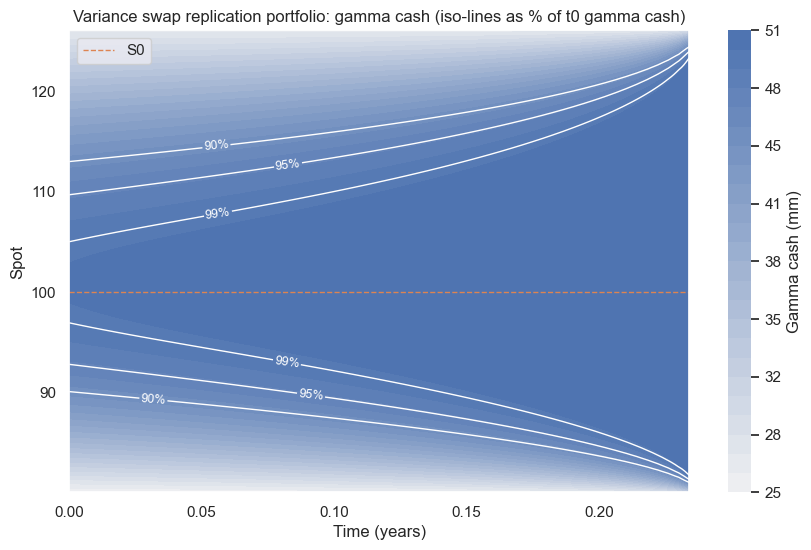

In [6]:
# Gamma cash (Gamma * S^2 / 100, P&L per 1% move squared) of each option position on a spot x time grid.
# The spot grid spans the strike range; the last time step is excluded since gamma is singular at expiry.
spot_grid = np.linspace(K_lower, K_upper, 200)
time_grid = np.linspace(0.0, T, n_steps + 1)[:-1]

gamma_cash_by_option = np.empty((spot_grid.size, time_grid.size, n_options))
for j, t in enumerate(time_grid):
    tau = T - t
    F_grid = spot_grid[:, None] * np.exp(r * tau)
    greeks = BSMModel.compute_option_with_forward(F_grid, strikes[None, :], tau, r, sigma, "call", compute_greeks=True)
    gamma_spot = greeks["gamma"] * np.exp(2 * r * tau)     # forward gamma -> spot gamma (same for calls and puts)
    gamma_cash_by_option[:, j] = gamma_spot * quantities * spot_grid[:, None] ** 2 / 100
gamma_cash = gamma_cash_by_option.sum(axis=2)

# Filled contours in millions, with labelled iso-lines at fractions of the t0 target to show where the replication holds
gamma_cash_mm = gamma_cash / 1e6
fill_levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)
line_levels = t0_gamma_cash / 1e6 * np.array([0.90, 0.95, 0.99])

# Sequential colormap built from the seaborn theme palette (same blue as the terminal payoff plot)
theme_cmap = sns.light_palette(sns.color_palette()[0], as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 6))
filled = ax.contourf(time_grid, spot_grid, gamma_cash_mm, levels=fill_levels, cmap=theme_cmap)
lines = ax.contour(time_grid, spot_grid, gamma_cash_mm, levels=line_levels, colors="white", linewidths=1)
ax.clabel(lines, fmt=lambda v: f"{v / (t0_gamma_cash / 1e6):.0%}", fontsize=9)
cbar = fig.colorbar(filled, ax=ax, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--", label="S0")
ax.grid(False)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Spot")
ax.set_title("Variance swap replication portfolio: gamma cash (iso-lines as % of t0 gamma cash)")
ax.legend(loc="upper left", frameon=True)
plt.show()

### Terminal Payoff

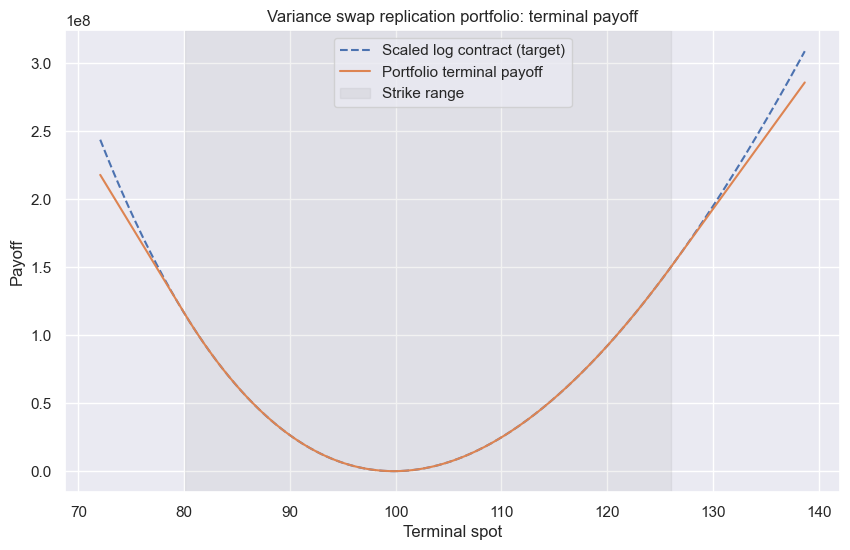

In [7]:
# Terminal payoff of the scaled portfolio vs the scaled log contract it replicates.
# The target includes the linear term from holding only a call at S_star: scale * [f(S) - slope_left * (S - S_star)].
terminal_spot = np.linspace(0.9 * K_lower, 1.1 * K_upper, 1_000)
intrinsic = intrinsic_values(terminal_spot)
terminal_payoff = intrinsic @ quantities
target_payoff = scale * (log_contract(terminal_spot) - slope_left_star * (terminal_spot - S_star))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, target_payoff, linestyle="--", label="Scaled log contract (target)")
ax.plot(terminal_spot, terminal_payoff, label="Portfolio terminal payoff")
ax.axvspan(K_lower, K_upper, alpha=0.1, color="gray", label="Strike range")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Variance swap replication portfolio: terminal payoff")
ax.legend(loc="upper center")
plt.show()

### Montecarlo simulation

In [8]:
# Simulate GBM spot paths with simulation_sigma; options are priced and delta hedged daily with the pricing sigma
spot_paths = BSMModel.compute_montecarlo(S0, T, r, 0.0, 0.0, simulation_sigma, n_steps, n_paths, seed=True, seed_value=seed).to_numpy().T
dt = T / n_steps
step_index = pd.RangeIndex(1, n_steps + 1, name="step")                    # step i is the P&L over day i (from step i-1 to i)
spot_step_index = pd.RangeIndex(0, n_steps + 1, name="step")               # spot fixings, step 0 is S0

# Option values and spot deltas on every path, step and strike: shape (n_paths, n_steps + 1, n_options)
values = np.empty((n_paths, n_steps + 1, n_options))
deltas = np.zeros((n_paths, n_steps + 1, n_options))
for j in range(n_steps + 1):
    tau = T - j * dt
    if j == n_steps:
        values[:, j] = intrinsic_values(spot_paths[:, j])
        continue
    F_j = spot_paths[:, j][:, None] * np.exp(r * tau)
    for option_type, mask in (("call", is_call), ("put", ~is_call)):
        res = BSMModel.compute_option_with_forward(F_j, strikes[mask], tau, r, sigma, option_type, compute_greeks=True)
        values[:, j, mask] = res["price"]
        deltas[:, j, mask] = res["delta"] * np.exp(r * tau)      # forward delta -> spot delta

# Daily position P&L (scaled by quantity). The hedge is short delta in spot, with the cash account financed at r.
dS = np.diff(spot_paths, axis=1)[:, :, None]
option_pnl = np.diff(values, axis=1) * quantities
delta_hedge_pnl = (-deltas[:, :-1] * dS + r * dt * (deltas[:, :-1] * spot_paths[:, :-1, None] - values[:, :-1])) * quantities
delta_hedged_option_pnl = option_pnl + delta_hedge_pnl
portfolio_pnl = delta_hedged_option_pnl.sum(axis=2)

# result_dict[path] -> {"option", "delta_hedge", "delta_hedged_option": DataFrame(step x option),
#                      "portfolio_delta_hedged": DataFrame(step x portfolio), "spot_timeseries": DataFrame(step x spot)}
result_dict = {
    path: {
        "option": pd.DataFrame(option_pnl[path], index=step_index, columns=option_names),
        "delta_hedge": pd.DataFrame(delta_hedge_pnl[path], index=step_index, columns=option_names),
        "delta_hedged_option": pd.DataFrame(delta_hedged_option_pnl[path], index=step_index, columns=option_names),
        "portfolio_delta_hedged": pd.DataFrame({"portfolio": portfolio_pnl[path]}, index=step_index),
        "spot_timeseries": pd.DataFrame({"spot": spot_paths[path]}, index=spot_step_index),
    }
    for path in range(n_paths)
}

# Sanity check: with simulation_sigma == sigma the delta hedged portfolio P&L should be centred on zero
total_portfolio_pnl = portfolio_pnl.sum(axis=1)
print(f"Portfolio premium: {(portfolio['quantity'] * portfolio['price']).sum():,.0f}")
print(f"Delta hedged portfolio total P&L: mean = {total_portfolio_pnl.mean():,.0f}, std = {total_portfolio_pnl.std():,.0f}")
# Per-path summary: annualised realised volatility (zero-mean, variance swap convention) and total hedged portfolio P&L
log_returns = np.diff(np.log(spot_paths), axis=1)
summary = pd.DataFrame(
    {
        "realized_volatility": np.sqrt((log_returns ** 2).sum(axis=1) / T),
        "portfolio_hedged_pnl": total_portfolio_pnl,
    },
    index=pd.RangeIndex(n_paths, name="path"),
)
display(summary.head())

Portfolio premium: 24,181,580
Delta hedged portfolio total P&L: mean = 37,530, std = 4,325,265


,realized_volatility,portfolio_hedged_pnl
path,,
0,0.183,-3_900_871
1,0.1871,-3_038_892
2,0.1983,-360_041
3,0.2058,1_576_707
4,0.2072,1_732_989


### P&L reduction

Portfolio P&L std = 4_325_481
Lasso: 10 of 100 options, hedged P&L R2 = 0.9902, tracking error std = 428_614
OMP: 10 of 100 options, hedged P&L R2 = 0.9933, tracking error std = 353_893


,strike,option_type,quantity,multiplier,reduced_quantity
put_84.25,84.25,put,333_808,9.415,3_142_947
put_87.04,87.04,put,312_760,5.48,1_713_780
put_89.83,89.83,put,293_642,6.113,1_795_079
put_92.62,92.62,put,276_225,6.236,1_722_463
put_95.41,95.41,put,260_312,6.469,1_683_903
put_98.66,98.66,put,243_427,7.83,1_905_993
call_102.38,102.4,call,226_065,7.845,1_773_389
call_105.63,105.6,call,212_354,7.122,1_512_401
call_109.35,109.4,call,198_157,9.146,1_812_438
call_114.47,114.5,call,180_850,16.74,3_027_346


,full,reduced,diff,ok
delta,97_327,-283_858,-381_185,NaN
gamma_cash,50_000_000,49_999_993,-6.79,True
theta,-396_825,-396_825,0.05389,True
vega,2_380_952,2_380_952,-0.3233,True
slide_-5%,6_434_675,6_451_089,16_414,True
slide_-10%,26_329_471,26_329_468,-2.32,True


,strike,option_type,quantity,multiplier,reduced_quantity
put_81.93,81.93,put,353_014,8.147,2_875_985
put_85.65,85.65,put,323_027,8.453,2_730_622
put_89.83,89.83,put,293_642,9.598,2_818_278
put_94.48,94.48,put,265_460,9.581,2_543_367
put_98.66,98.66,put,243_427,7.92,1_927_883
call_101.92,101.9,call,228_132,8.002,1_825_538
call_106.1,106.1,call,210_497,7.718,1_624_641
call_108.89,108.9,call,199_853,7.5,1_498_990
call_113.54,113.5,call,183_824,12.14,2_232_457
call_120.97,121,call,161_917,17.73,2_871_485


,full,reduced,diff,ok
delta,97_327,-137_952,-235_279,NaN
gamma_cash,50_000_000,50_000_000,7.451e-09,True
theta,-396_825,-396_825,0,True
vega,2_380_952,2_380_952,4.657e-10,True
slide_-5%,6_434_675,6_436_625,1_950,True
slide_-10%,26_329_471,26_333_394,3_923,True


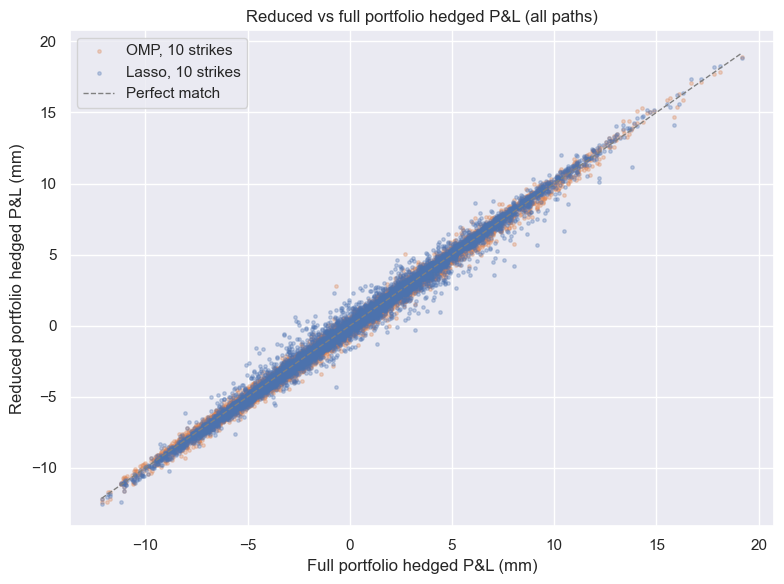

In [9]:
# Features: total delta hedged P&L of each option position per path (same as result_dict[path]["delta_hedged_option"].sum()).
# Target: total delta hedged portfolio P&L per path. Using quantity-scaled positions makes each coefficient a multiplier
# of the original quantity (the full portfolio is all ones). All paths are used: this is a theoretical fit, not a forecast.
X = pd.DataFrame(delta_hedged_option_pnl.sum(axis=1), index=summary.index, columns=option_names)
y = summary["portfolio_hedged_pnl"]

# t0 risk constraints on (reduced - full portfolio), passed to constrained_lasso for every objective
risk_constraints = {"floors": ["gamma_cash", "theta", *slide_columns], "bands": {"vega": vega_tolerance}}

pnl_best = constrained_lasso(X, y, risk_positions, n_selected_options, **risk_constraints)
reduced_pnl_portfolio = reduced_positions(pnl_best)
summary["reduced_hedged_pnl"] = reduced_pnl(reduced_pnl_portfolio)

# OMP under the same risk constraints: greedy selection, constrained least squares fit and swaps (see omp)
pnl_omp = omp(X, y, risk_positions, n_selected_options, **risk_constraints)
reduced_pnl_omp_portfolio = reduced_positions(pnl_omp)
summary["omp_hedged_pnl"] = reduced_pnl(reduced_pnl_omp_portfolio)

print(f"Portfolio P&L std = {y.std():_.0f}")
for name, fit, col in (("Lasso", pnl_best, "reduced_hedged_pnl"), ("OMP", pnl_omp, "omp_hedged_pnl")):
    tracking_error = summary["portfolio_hedged_pnl"] - summary[col]
    print(f"{name}: {len(fit.weights)} of {n_options} options, hedged P&L R2 = {fit.r2:.4f}, "
          f"tracking error std = {tracking_error.std():_.0f}")
display(reduced_pnl_portfolio)
display(pnl_best.risk_check)
display(reduced_pnl_omp_portfolio)
display(pnl_omp.risk_check)

# Reduced vs full portfolio hedged P&L on every path
palette = sns.color_palette()
lims = np.array([y.min(), y.max()]) / 1e6

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y / 1e6, summary["omp_hedged_pnl"] / 1e6, s=6, alpha=0.3, color=palette[1], label=f"OMP, {len(pnl_omp.weights)} strikes")
ax.scatter(y / 1e6, summary["reduced_hedged_pnl"] / 1e6, s=6, alpha=0.3, color=palette[0], label=f"Lasso, {len(pnl_best.weights)} strikes")
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="Perfect match")
ax.set_xlabel("Full portfolio hedged P&L (mm)")
ax.set_ylabel("Reduced portfolio hedged P&L (mm)")
ax.set_title("Reduced vs full portfolio hedged P&L (all paths)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
method_quantities = {
    "Full portfolio": portfolio.set_index("strike")["quantity"],
    "Lasso (P&L)": reduced_pnl_portfolio.set_index("strike")["reduced_quantity"],
    "OMP (P&L)": reduced_pnl_omp_portfolio.set_index("strike")["reduced_quantity"],
}

### Terminal payoff reduction

Lasso: 10 of 100 options, terminal payoff R2 = 0.9993, hedged P&L R2 = 0.9841
OMP: 10 of 100 options, terminal payoff R2 = 0.9997, hedged P&L R2 = 0.9912


,strike,option_type,quantity,multiplier,reduced_quantity
strike,,,,,
put_81.0,81,put,361_164,3.192,1_152_682
put_85.65,85.65,put,323_027,16.27,5_254_822
put_92.62,92.62,put,276_225,9.788,2_703_624
put_94.48,94.48,put,265_460,7.497,1_990_152
put_99.59,99.59,put,238_903,5.132,1_225_936
call_100.06,100.1,call,236_689,3.194,755_987
call_103.78,103.8,call,220_031,10.48,2_305_331
call_107.96,108,call,203_309,8.447,1_717_281
call_113.07,113.1,call,185_338,13.5,2_502_271


,full,reduced,diff,ok
delta,97_327,96_579,-748.2,NaN
gamma_cash,50_000_000,49_999_959,-40.66,True
theta,-396_825,-396_825,0.3227,True
vega,2_380_952,2_380_950,-1.936,True
slide_-5%,6_434_675,6_436_701,2_026,True
slide_-10%,26_329_471,26_329_446,-24.48,True


,strike,option_type,quantity,multiplier,reduced_quantity
strike,,,,,
put_83.79,83.79,put,337_522,13.37,4_513_683
put_88.9,88.9,put,299_815,10.17,3_048_981
put_93.55,93.55,put,270_762,8.585,2_324_364
put_96.34,96.34,put,255_313,4.433,1_131_794
put_98.66,98.66,put,243_427,5.244,1_276_494
call_100.06,100.1,call,236_689,3.993,945_194
call_104.24,104.2,call,218_073,10.46,2_280_730
call_108.89,108.9,call,199_853,10.84,2_166_229
call_114.93,114.9,call,179_391,15.24,2_734_328


,full,reduced,diff,ok
delta,97_327,98_211,883.9,NaN
gamma_cash,50_000_000,50_000_000,1.416e-07,True
theta,-396_825,-396_825,-1.164e-09,True
vega,2_380_952,2_380_952,7.451e-09,True
slide_-5%,6_434_675,6_436_350,1_675,True
slide_-10%,26_329_471,26_329_471,5.442e-05,True


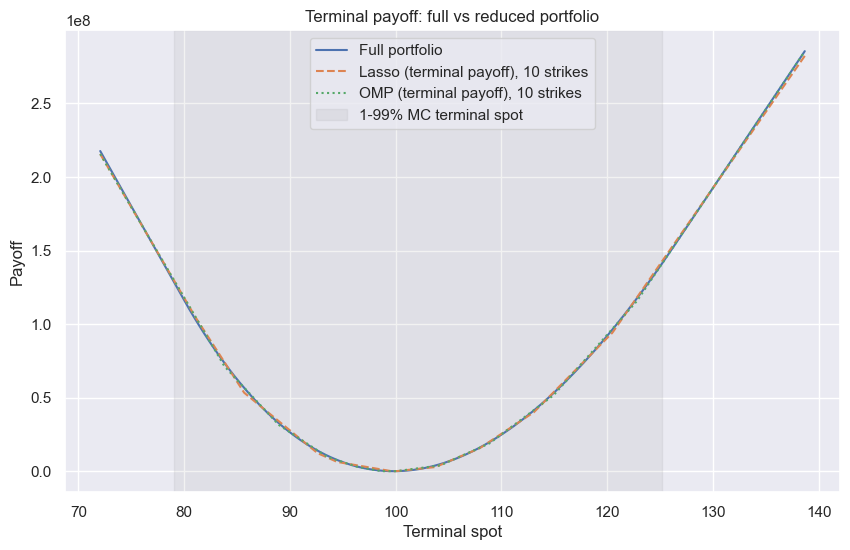

In [11]:
# Replicate the terminal payoff of the full portfolio under the t0 risk constraints. The payoffs are sampled at the
# Monte Carlo terminal spots, so strikes are weighted by how likely the spot ends there.
# Inputs are indexed by terminal spot level (rows) and option strike (columns / risk index).
terminal_spots = spot_paths[:, -1]
option_terminal_payoff = pd.DataFrame(
    intrinsic_values(terminal_spots) * quantities,
    index=pd.Index(terminal_spots, name="terminal_spot"), columns=pd.Index(strikes, name="strike"),
)
portfolio_terminal_payoff = option_terminal_payoff.sum(axis=1)
risk_by_strike = risk_positions.set_axis(option_terminal_payoff.columns)

payoff_best = weights_by_name(terminal_payoff_lasso(
    portfolio_terminal_payoff, option_terminal_payoff, n_selected_options,
    t0_risk=risk_by_strike, risk_floor=risk_constraints["floors"], risk_tolerance=risk_constraints["bands"],
))
reduced_payoff_portfolio = reduced_positions(payoff_best)
payoff_omp = weights_by_name(omp(
    option_terminal_payoff, portfolio_terminal_payoff, risk_by_strike, n_selected_options, **risk_constraints
))
reduced_payoff_omp_portfolio = reduced_positions(payoff_omp)
for name, fit, reduced in (("Lasso", payoff_best, reduced_payoff_portfolio), ("OMP", payoff_omp, reduced_payoff_omp_portfolio)):
    print(f"{name}: {len(fit.weights)} of {n_options} options, terminal payoff R2 = {fit.r2:.4f}, "
          f"hedged P&L R2 = {pnl_r2(reduced):.4f}")
display(reduced_payoff_portfolio)
display(payoff_best.risk_check)
display(reduced_payoff_omp_portfolio)
display(payoff_omp.risk_check)

# Terminal payoff of the full vs reduced portfolio on the same spot grid as the Terminal Payoff section
intrinsic_df = pd.DataFrame(intrinsic, columns=option_names)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, terminal_payoff, label="Full portfolio")
ax.plot(terminal_spot, grid_payoff(reduced_payoff_portfolio), linestyle="--", label=f"Lasso (terminal payoff), {len(payoff_best.weights)} strikes")
ax.plot(terminal_spot, grid_payoff(reduced_payoff_omp_portfolio), linestyle=":", label=f"OMP (terminal payoff), {len(payoff_omp.weights)} strikes")
ax.axvspan(*np.percentile(terminal_spots, [1, 99]), alpha=0.1, color="gray", label="1-99% MC terminal spot")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Terminal payoff: full vs reduced portfolio")
ax.legend(loc="upper center")
plt.show()

method_quantities["Lasso (terminal payoff)"] = reduced_payoff_portfolio.set_index("strike")["reduced_quantity"]
method_quantities["OMP (terminal payoff)"] = reduced_payoff_omp_portfolio.set_index("strike")["reduced_quantity"]

### Gamma grid reduction

Lasso: 10 of 100 options, gamma grid R2 = 0.8022, hedged P&L R2 = 0.9914
OMP: 10 of 100 options, gamma grid R2 = 0.8730, hedged P&L R2 = 0.9930


,strike,option_type,quantity,multiplier,reduced_quantity
put_83.79,83.79,put,337_522,10.89,3_674_302
put_87.04,87.04,put,312_760,6.618,2_069_731
put_91.23,91.23,put,284_734,10.39,2_958_351
put_95.87,95.87,put,257_794,9.409,2_425_513
call_100.06,100.1,call,236_689,9.785,2_316_065
call_105.17,105.2,call,214_235,11.65,2_496_477
call_110.75,110.7,call,193_199,11.63,2_246_215
call_115.4,115.4,call,177_948,7.533,1_340_436
call_119.11,119.1,call,167_012,9.763,1_630_519
call_123.76,123.8,call,154_702,8.917,1_379_476


,full,reduced,diff,ok
delta,97_327,1_044_769,947_442,NaN
gamma_cash,50_000_000,49_999_999,-0.8251,True
theta,-396_825,-396_825,0.006548,True
vega,2_380_952,2_380_952,-0.03929,True
slide_-5%,6_434_675,6_439_547,4_872,True
slide_-10%,26_329_471,26_329_470,-0.9134,True


,strike,option_type,quantity,multiplier,reduced_quantity
put_82.39,82.39,put,349_043,9.029,3_151_355
put_86.11,86.11,put,319_549,6.842,2_186_469
put_88.9,88.9,put,299_815,6.784,2_034_013
put_92.62,92.62,put,276_225,8.274,2_285_354
put_96.34,96.34,put,255_313,7.655,1_954_323
call_100.06,100.1,call,236_689,9.488,2_245_776
call_105.17,105.2,call,214_235,11.61,2_486_834
call_110.75,110.7,call,193_199,12.5,2_414_810
call_116.79,116.8,call,173_724,13.13,2_281_206
call_122.83,122.8,call,157_053,13.13,2_062_108


,full,reduced,diff,ok
delta,97_327,1_006_238,908_911,NaN
gamma_cash,50_000_000,50_000_000,-3.353e-07,True
theta,-396_825,-396_825,2.619e-09,True
vega,2_380_952,2_380_952,-1.537e-08,True
slide_-5%,6_434_675,6_436_396,1_721,True
slide_-10%,26_329_471,26_332_626,3_155,True


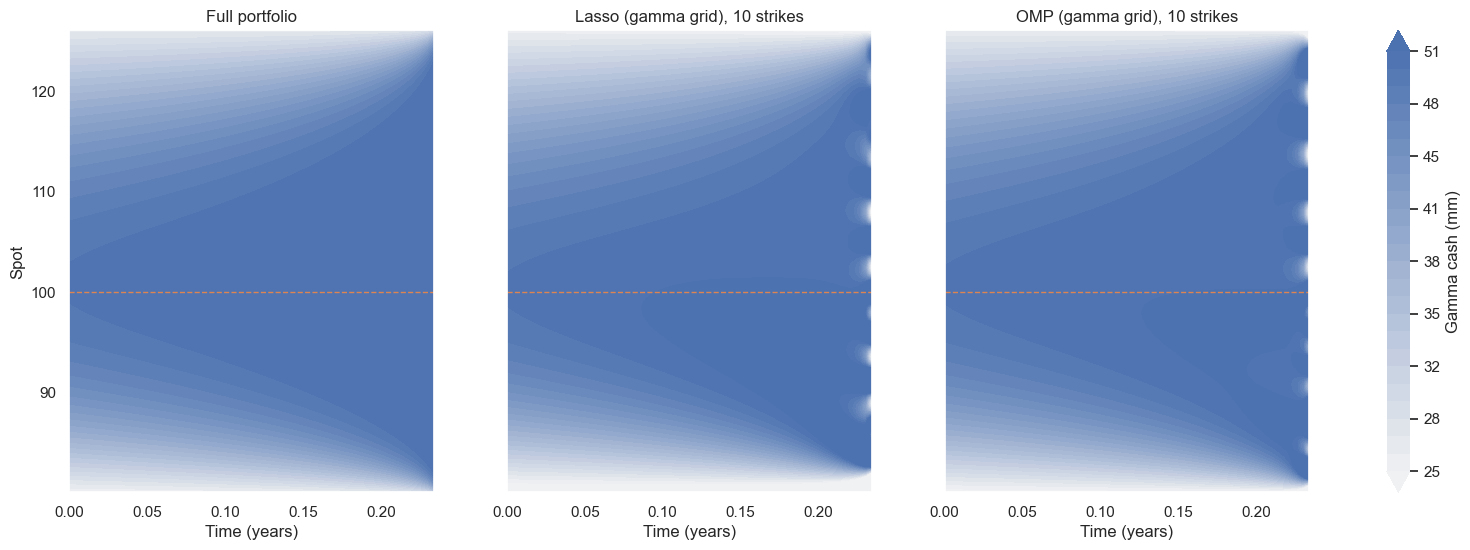

In [12]:
# Features: gamma cash of each option position on the Gamma Grid (spot x time); target: gamma cash of the full portfolio.
# Every grid point has the same weight.
X_gamma = pd.DataFrame(gamma_cash_by_option.reshape(-1, n_options), columns=option_names)
y_gamma = X_gamma.sum(axis=1)

gamma_best = constrained_lasso(X_gamma, y_gamma, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_portfolio = reduced_positions(gamma_best)
gamma_omp = omp(X_gamma, y_gamma, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_omp_portfolio = reduced_positions(gamma_omp)
for name, fit, reduced in (("Lasso", gamma_best, reduced_gamma_portfolio), ("OMP", gamma_omp, reduced_gamma_omp_portfolio)):
    print(f"{name}: {len(fit.weights)} of {n_options} options, gamma grid R2 = {fit.r2:.4f}, "
          f"hedged P&L R2 = {pnl_r2(reduced):.4f}")
display(reduced_gamma_portfolio)
display(gamma_best.risk_check)
display(reduced_gamma_omp_portfolio)
display(gamma_omp.risk_check)

# Gamma grid of the full vs reduced portfolio on the full portfolio's colour scale (reduced spikes near expiry saturate)
levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, grid, title in zip(axes,
                           (gamma_cash_mm, grid_gamma_cash_mm(reduced_gamma_portfolio), grid_gamma_cash_mm(reduced_gamma_omp_portfolio)),
                           ("Full portfolio", f"Lasso (gamma grid), {len(gamma_best.weights)} strikes",
                            f"OMP (gamma grid), {len(gamma_omp.weights)} strikes")):
    filled = ax.contourf(time_grid, spot_grid, grid, levels=levels, cmap=theme_cmap, extend="both")
    ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--")
    ax.grid(False)
    ax.set_xlabel("Time (years)")
    ax.set_title(title)
axes[0].set_ylabel("Spot")
cbar = fig.colorbar(filled, ax=axes, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
plt.show()

# Comparison of the reductions on the common hedged P&L yardstick
reductions = {
    ("P&L", "Lasso"): (pnl_best, reduced_pnl_portfolio),
    ("P&L", "OMP"): (pnl_omp, reduced_pnl_omp_portfolio),
    ("terminal payoff", "Lasso"): (payoff_best, reduced_payoff_portfolio),
    ("terminal payoff", "OMP"): (payoff_omp, reduced_payoff_omp_portfolio),
    ("gamma grid", "Lasso"): (gamma_best, reduced_gamma_portfolio),
    ("gamma grid", "OMP"): (gamma_omp, reduced_gamma_omp_portfolio),
}

### Comparison

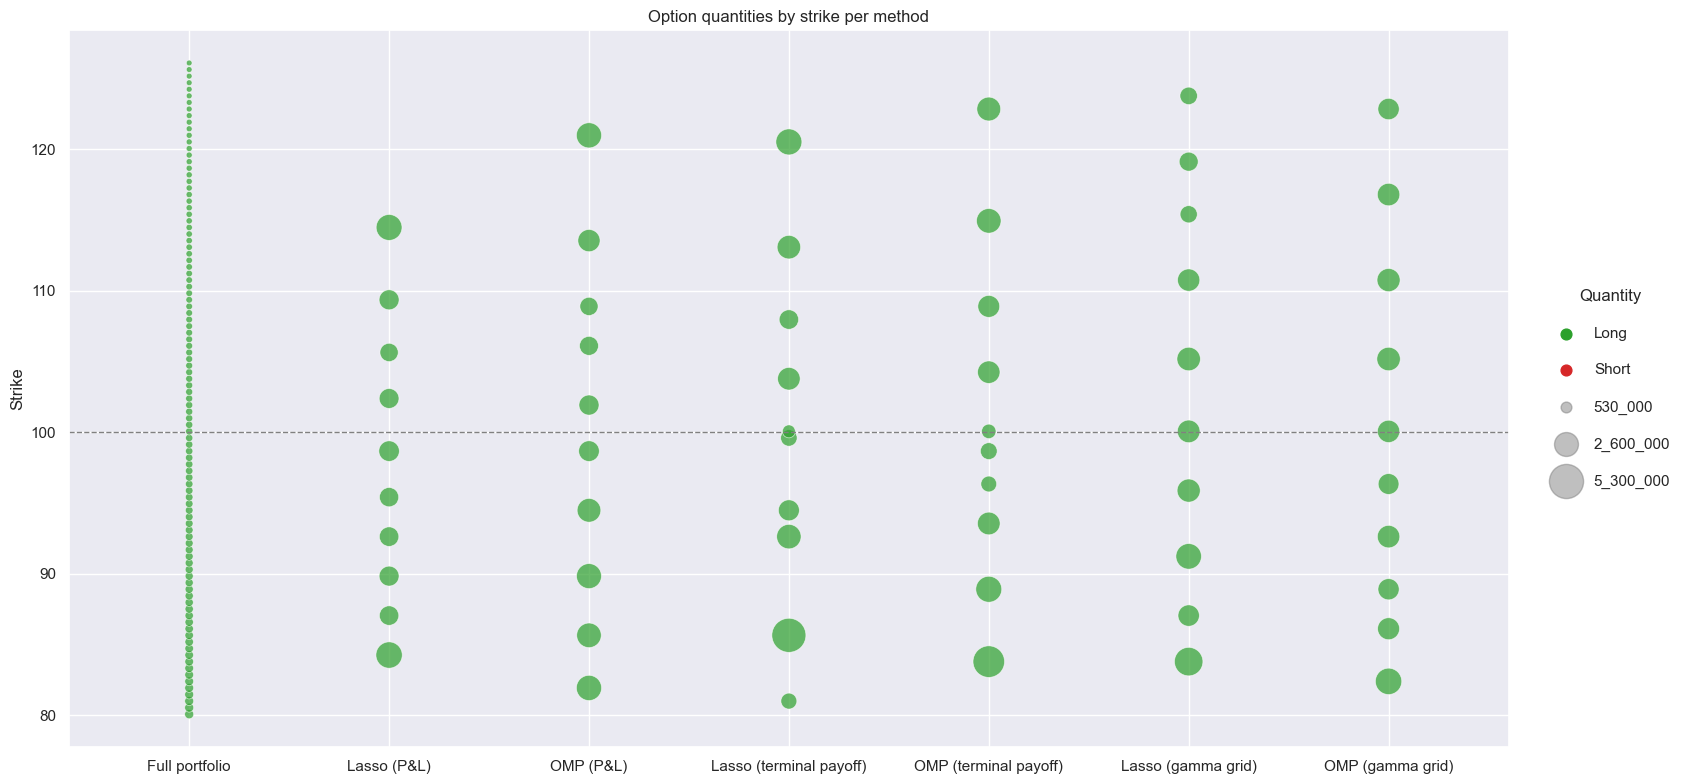

n_strikes  own_objective_r2  hedged_pnl_r2  \
objective       algorithm                                               
full portfolio  -                100                 1              1   
P&L             Lasso             10            0.9902         0.9902   
                OMP               10            0.9933         0.9933   
terminal payoff Lasso             10            0.9993         0.9841   
                OMP               10            0.9997         0.9912   
gamma grid      Lasso             10            0.8022         0.9914   
                OMP               10             0.873          0.993   

                           hedged_pnl_std  tracking_error_std  
objective       algorithm                                      
full portfolio  -               4_325_481                   0  
P&L             Lasso           4_368_000             428_614  
                OMP             4_343_510             353_893  
terminal payoff Lasso           4_359_962             545_590  
                OMP             4_349_725             406_311  
gamma grid      Lasso           4_345_950             402_208  
                OMP             4_337_774             360_616

full portfolio      P&L           terminal payoff             \
                        -    Lasso       OMP           Lasso        OMP   
delta              97_327 -381_185  -235_279          -748.2      883.9   
gamma_cash     50_000_000    -6.79 7.451e-09          -40.66  1.416e-07   
theta            -396_825  0.05389         0          0.3227 -1.164e-09   
vega            2_380_952  -0.3233 4.657e-10          -1.936  7.451e-09   
slide_-5%       6_434_675   16_414     1_950           2_026      1_675   
slide_-10%     26_329_471    -2.32     3_923          -24.48  5.442e-05   

           gamma grid             
                Lasso        OMP  
delta         947_442    908_911  
gamma_cash    -0.8251 -3.353e-07  
theta        0.006548  2.619e-09  
vega         -0.03929 -1.537e-08  
slide_-5%       4_872      1_721  
slide_-10%    -0.9134      3_155

Constraints satisfied: {'P&L / Lasso': True, 'P&L / OMP': True, 'terminal payoff / Lasso': True, 'terminal payoff / OMP': True, 'gamma grid / Lasso': True, 'gamma grid / OMP': True}


In [13]:
method_quantities["Lasso (gamma grid)"] = reduced_gamma_portfolio.set_index("strike")["reduced_quantity"]
method_quantities["OMP (gamma grid)"] = reduced_gamma_omp_portfolio.set_index("strike")["reduced_quantity"]
plot_strike_map(method_quantities)


comparison = pd.DataFrame(
    {
        "n_strikes": [len(reduced) for _, reduced in reductions.values()],
        "own_objective_r2": [fit.r2 for fit, _ in reductions.values()],
        "hedged_pnl_r2": [pnl_r2(reduced) for _, reduced in reductions.values()],
        "hedged_pnl_std": [reduced_pnl(reduced).std() for _, reduced in reductions.values()],
        "tracking_error_std": [(y - reduced_pnl(reduced)).std() for _, reduced in reductions.values()],
    },
    index=pd.MultiIndex.from_tuples(reductions.keys(), names=["objective", "algorithm"]),
)
# Reference row: the full portfolio (tracking error is zero by construction)
comparison.loc[("full portfolio", "-"), :] = [n_options, 1.0, 1.0, y.std(), 0.0]
comparison = comparison.astype({"n_strikes": int}).iloc[[-1, *range(len(reductions))]]
display(comparison)

# t0 risk check of every reduction: (reduced - full portfolio) per metric, and whether all constraints hold
# (enforced by both algorithms)
risk_check = pd.DataFrame({key: fit.risk_check["diff"] for key, (fit, _) in reductions.items()})
risk_check.insert(0, ("full portfolio", "-"), full_risk)
display(risk_check)
print("Constraints satisfied:", {f"{objective} / {algorithm}": bool(fit.risk_check["ok"].dropna().all())
                                 for (objective, algorithm), (fit, _) in reductions.items()})

### Sample use: terminal payoff OMP

put_83.79     4_430_992
put_88.9      2_908_709
put_93.55     3_147_231
put_98.66     1_760_163
call_100.06     976_844
call_104.24   2_052_257
call_108.89   2_886_979
call_118.18   4_152_058
dtype: float64

,portfolio,reduced,diff,ok
delta,97_327,97_848,520.9,NaN
gamma_cash,50_000_000,50_000_000,-1.49e-08,True
theta,-396_825,-396_825,5.821e-11,True
vega,2_380_952,2_380_952,0,True
slide_-5%,6_434_675,6_437_093,2_418,True
slide_-10%,26_329_471,26_329_471,6.301e-05,True
bid_offer,-41_176_871,-32_941_497,8_235_374,True


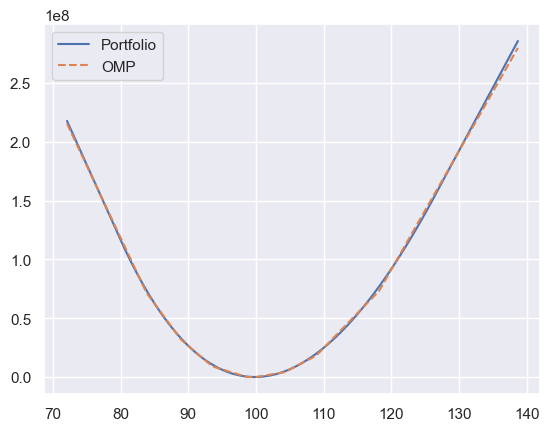

In [14]:
# Reduce the notebook portfolio to 8 options matching its terminal payoff under the t0 risk constraints, losing at
# most 80% of the full portfolio bid-offer P&L
portfolio_weight = portfolio.set_index("name")["quantity"]
option_terminal_payoff = pd.DataFrame(intrinsic_values(terminal_spots), index=terminal_spots, columns=option_names)
risk_t0 = risk_positions.div(quantities, axis=0)                          # unit risk per option

option_bid_offer = pd.Series(index=option_terminal_payoff.columns, data=0.0)
option_bid_offer.loc[:] = [(float(x.split('_')[1]) - 100)**2 * -0.01 for x in option_bid_offer.index]

result = quick_terminal_payoff_omp(portfolio_weight, option_terminal_payoff, risk_t0,
                                   risk_floor=["gamma_cash", "theta", "slide_-5%", "slide_-10%"],
                                   risk_tolerance={"vega": 0.05}, max_position=8,
                                   option_bid_offer=option_bid_offer, pnl_haircut=0.8)
display(result.weights, result.risk_check)

plt.plot(terminal_spot, intrinsic @ quantities, label="Portfolio")
plt.plot(terminal_spot, pd.DataFrame(intrinsic, columns=option_names)[result.weights.index] @ result.weights, "--", label="OMP")
plt.legend()
plt.show()

### Sample use: terminal payoff Lasso

put_86.11     6_347_492
put_90.76       358_847
put_94.48     3_954_444
put_99.59       991_865
call_100.06     337_726
call_103.78   3_698_474
call_113.54   3_932_879
call_120.97   2_072_443
dtype: float64

,portfolio,reduced,diff,ok
delta,97_327,98_319,992.2,NaN
gamma_cash,50_000_000,49_999_997,-2.888,True
theta,-396_825,-396_825,0.02292,True
vega,2_380_952,2_380_952,-0.1375,True
slide_-5%,6_434_675,6_441_847,7_172,True
slide_-10%,26_329_471,26_329_469,-1.712,True
bid_offer,-41_176_871,-30_611_378,10_565_493,True


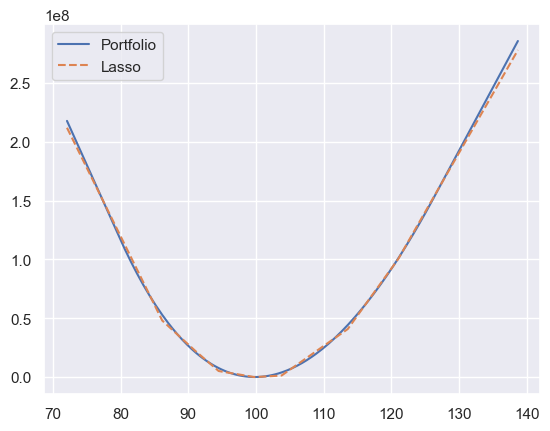

In [17]:
# Same reduction with the constrained lasso, plus a bid-offer constraint: the reduced portfolio loses at most
# 80% of the full portfolio bid-offer P&L
option_bid_offer = pd.Series(index=option_terminal_payoff.columns, data=0.0)
option_bid_offer.loc[:] = [(float(x.split('_')[1]) - 100)**2 * -0.01 for x in option_bid_offer.index]
result = quick_terminal_payoff_lasso(portfolio_weight, option_terminal_payoff, risk_t0,
                                     risk_floor=["gamma_cash", "theta", "slide_-5%", "slide_-10%"],
                                     risk_tolerance={"vega": 0.05}, max_position=8,
                                     option_bid_offer=option_bid_offer, pnl_haircut=0.8)
display(result.weights, result.risk_check)

plt.plot(terminal_spot, intrinsic @ quantities, label="Portfolio")
plt.plot(terminal_spot, pd.DataFrame(intrinsic, columns=option_names)[result.weights.index] @ result.weights, "--", label="Lasso")
plt.legend()
plt.show()